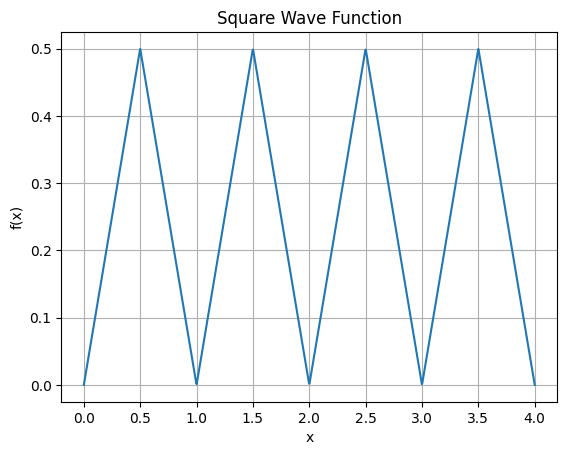

1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f0(x):
    """
    Square wave function
    """
    if isinstance(x, np.ndarray):
        return np.where(np.floor(2 * x) % 2 == 0, 0,1)
    else:
        return 0 if np.floor(2 * x) % 2 == 0 else 1

def f2(x):
    """
    Triangle wave function
    """
    if isinstance(x, np.ndarray):
        return np.abs( x -  np.floor(x + 0.5))
    else:
        return abs(x -  np.floor(x + 0.5))

def f4(x):
    """
    Rectified sine wave function
    """
    if isinstance(x, np.ndarray):
        return np.abs(np.sin(np.pi * x))
    else:
        return np.abs(np.sin(np.pi * x))


def plot_wave(function):
    x = np.linspace(0, 4, 1000)
    y = function(x)

    plt.plot(x, y)
    plt.title('Square Wave Function')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid()
    plt.show()


plot_wave(f2)
print(f4(1.5))

In [ ]:
def make_ecg_dict():
    """
    Create ecg data
    """
    ecg_dict = {}
    with open('types.txt', 'r') as file:
        for line in file:
            index, code, full_name = line.strip().split(',')
            index = int(index)
            ecg_dict[index] = (index, code, full_name)
            ecg_dict[code] = (index, code, full_name)
    return ecg_dict


data = make_ecg_dict()
print(data)

{1: (1, 'NSR', 'Normal sinus rhythm'), 'NSR': (1, 'NSR', 'Normal sinus rhythm'), 2: (2, 'APB', 'Atrial premature beat'), 'APB': (2, 'APB', 'Atrial premature beat'), 3: (3, 'AFL', 'Atrial flutter'), 'AFL': (3, 'AFL', 'Atrial flutter'), 4: (4, 'AFIB', 'Atrial fibrillation'), 'AFIB': (4, 'AFIB', 'Atrial fibrillation'), 5: (5, 'SVTA', 'Supraventricular tachyarrhythmia'), 'SVTA': (5, 'SVTA', 'Supraventricular tachyarrhythmia'), 6: (6, 'WPW', 'Pre-excitation (WPW)'), 'WPW': (6, 'WPW', 'Pre-excitation (WPW)'), 7: (7, 'PVC', 'Premature ventricular contraction'), 'PVC': (7, 'PVC', 'Premature ventricular contraction'), 8: (8, 'Bigeminy', 'Ventricular bigeminy'), 'Bigeminy': (8, 'Bigeminy', 'Ventricular bigeminy'), 9: (9, 'Trigeminy', 'Ventricular trigeminy'), 'Trigeminy': (9, 'Trigeminy', 'Ventricular trigeminy'), 10: (10, 'VT', 'Ventricular tachycardia'), 'VT': (10, 'VT', 'Ventricular tachycardia'), 11: (11, 'IVR', 'Idioventricular rhythm'), 'IVR': (11, 'IVR', 'Idioventricular rhythm'), 12: (12

In [71]:
ecg_dict = make_ecg_dict()
import scipy

def get_ecg_data(n):
    """
    Label data
    """
    global ecg_dict

    if type(n) is int:
        index = n
        code = ecg_dict[index][1]
        full_name = ecg_dict[index][2]
    else:
        code = n
        index = ecg_dict[code][0]
        full_name = ecg_dict[code][2]

    data = scipy.io.loadmat(f'{code}.mat')
    return (index, code, full_name, data["val"].flatten())


get_ecg_data(2)


(2,
 'APB',
 'Atrial premature beat',
 array([948, 947, 948, ..., 971, 970, 971], shape=(3600,), dtype=int16))